In [72]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
def exibir_metricas(y_true, y_pred, y_prob, nome_modelo="Modelo"):
    print(f"--- Métricas: {nome_modelo} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.3f}\n")
    
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["Good", "Bad"]))

In [73]:
# Carregamento dos dados de teste
X_test = joblib.load("../processed/X_test.pkl")
y_test = joblib.load("../processed/y_test.pkl")

rf_model = joblib.load("../models/random_forest_baseline.pkl")
best_rf = joblib.load("../models/random_forest_tuned.pkl")

## 1. Avaliação do Modelo Antigo (Baseline)

In [74]:
# Gerando predições com o modelo antigo
y_pred_antigo = rf_model.predict(X_test)
y_prob_antigo = rf_model.predict_proba(X_test)[:, 1]

exibir_metricas(y_test, y_pred_antigo, y_prob_antigo, nome_modelo="Random Forest Baseline")

--- Métricas: Random Forest Baseline ---
Accuracy : 0.730
Precision: 0.588
Recall   : 0.333
F1-score : 0.426
ROC-AUC  : 0.734

Classification Report:

              precision    recall  f1-score   support

        Good       0.76      0.90      0.82       140
         Bad       0.59      0.33      0.43        60

    accuracy                           0.73       200
   macro avg       0.67      0.62      0.62       200
weighted avg       0.71      0.73      0.70       200



## 2. Avaliação do Modelo Otimizado 

In [75]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

exibir_metricas(y_test, y_pred, y_prob, nome_modelo="Random Forest Otimizada")

--- Métricas: Random Forest Otimizada ---
Accuracy : 0.725
Precision: 0.532
Recall   : 0.700
F1-score : 0.604
ROC-AUC  : 0.765

Classification Report:

              precision    recall  f1-score   support

        Good       0.85      0.74      0.79       140
         Bad       0.53      0.70      0.60        60

    accuracy                           0.72       200
   macro avg       0.69      0.72      0.70       200
weighted avg       0.76      0.72      0.73       200



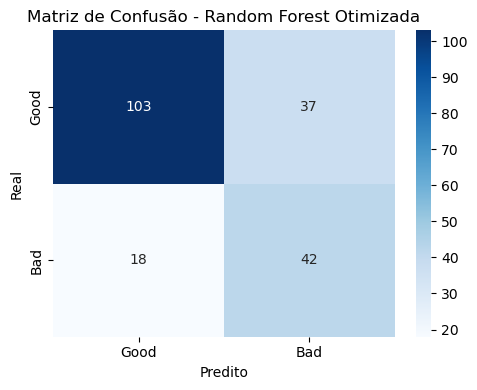

In [76]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Bad"],
    yticklabels=["Good", "Bad"]
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest Otimizada")
plt.tight_layout()
plt.show()


## Avaliação do Modelo com Ajuste de Limiar (Threshold)

--- Métricas: Random Forest Otimizada (Threshold: 0.47) ---
Accuracy : 0.695
Precision: 0.495
Recall   : 0.783
F1-score : 0.606
ROC-AUC  : 0.765

Classification Report:

              precision    recall  f1-score   support

        Good       0.88      0.66      0.75       140
         Bad       0.49      0.78      0.61        60

    accuracy                           0.69       200
   macro avg       0.69      0.72      0.68       200
weighted avg       0.76      0.69      0.71       200



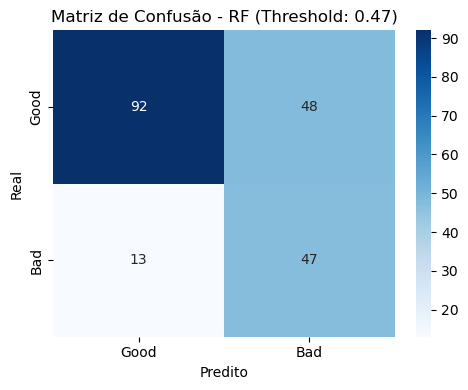

In [77]:
# 1. Definição do novo limite matemático
novo_limiar = 0.47
y_pred_personalizado = np.where(y_prob >= novo_limiar, 1, 0)

exibir_metricas(
    y_test, 
    y_pred_personalizado, 
    y_prob, 
    nome_modelo=f"Random Forest Otimizada (Threshold: {novo_limiar})"
)

#Matriz de Confusão
cm_personalizada = confusion_matrix(y_test, y_pred_personalizado)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_personalizada,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Bad"],
    yticklabels=["Good", "Bad"]
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title(f"Matriz de Confusão - RF (Threshold: {novo_limiar})")
plt.tight_layout()
plt.show()

## Curva ROC

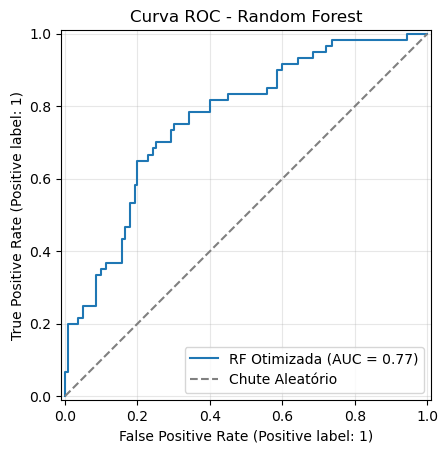

In [78]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob, 
    name=f"RF Otimizada"
)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Chute Aleatório')

plt.title("Curva ROC - Random Forest")
plt.grid(alpha=0.3)
plt.legend() 
plt.show()

## Importância das variáveis

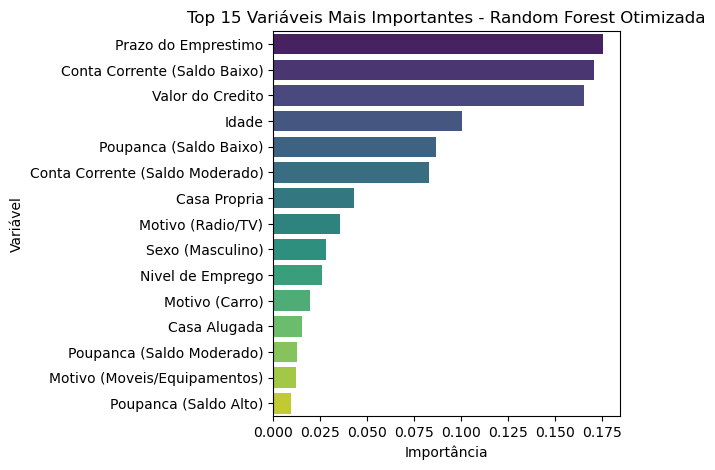

In [79]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Gráfico de importância
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="viridis" 
)

plt.title("Top 15 Variáveis Mais Importantes - Random Forest Otimizada")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()